# Boosting



## Rectangular Features

* Implementing the construction of all 2-rect features (horizontal and vertical) within a given window (like the 24x24 px window from the paper)
* Displaying three of these overlaid onto an image of a face.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, transform
# from tqdm.notebook import tqdm

# In case you don't have scikit-image installed, uncomment the following line:
# !pip install scikit-image

In [ ]:
WINDOW_SIZE = 24  # 24x24 as in the paper

def generate_two_rect_features(window_size=24):
    """
    Generate all 2-rectangle horizontal and vertical features
    inside a window_size x window_size window.

    Returns:
        features: list of dicts with keys:
                  type ('h2' or 'v2'), x, y, w, h
    """
    features = []

    # Horizontal 2-rect features: two rectangles side by side
    for h in range(1, window_size + 1):           # height of feature
        for w in range(2, window_size + 1, 2):    # total width, must be even
            for y in range(0, window_size - h + 1):
                for x in range(0, window_size - w + 1):
                    features.append({
                        "type": "h2",
                        "x": x,
                        "y": y,
                        "w": w,
                        "h": h
                    })

    # Vertical 2-rect features: two rectangles stacked
    for h in range(2, window_size + 1, 2):        # total height, must be even
        for w in range(1, window_size + 1):       # width of feature
            for y in range(0, window_size - h + 1):
                for x in range(0, window_size - w + 1):
                    features.append({
                        "type": "v2",
                        "x": x,
                        "y": y,
                        "w": w,
                        "h": h
                    })

    return features

features = generate_two_rect_features(WINDOW_SIZE)
print("Number of 2-rect features (horizontal + vertical) in a 24x24 window:", len(features))


Number of 2-rect features (horizontal + vertical) in a 24x24 window: 86400


example_face shape: (24, 24)


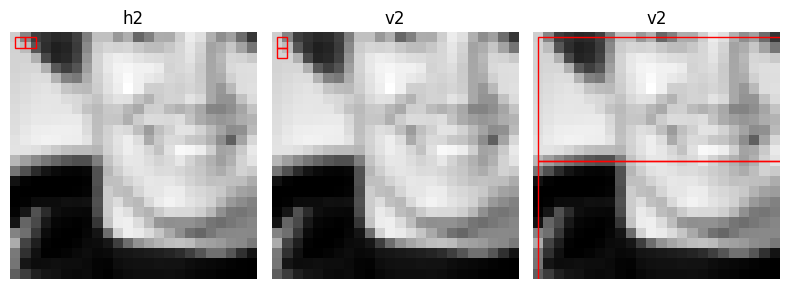

In [ ]:
from skimage import data
from skimage import color
from skimage.transform import resize

# Load astronaut image
astronaut_img = data.astronaut()  # returns RGB image
face_crop = astronaut_img[100:200, 150:250]  # rough face region
example_face = resize(face_crop, (24, 24), anti_aliasing=True)
example_face = color.rgb2gray(example_face)  # to grayscale
print("example_face shape:", example_face.shape)


def plot_feature_on_image(img, feature, ax=None):
    if ax is None:
        ax = plt.gca()
    ax.imshow(img, cmap='gray')
    ax.axis('off')

    x, y, w, h = feature["x"], feature["y"], feature["w"], feature["h"]
    if feature["type"] == "h2":
        # left (white) and right (black) rectangles
        rects = [
            (x, y, w // 2, h, "white"),
            (x + w // 2, y, w // 2, h, "black")
        ]
    else:  # 'v2'
        # top (white) and bottom (black) rectangles
        rects = [
            (x, y, w, h // 2, "white"),
            (x, y + h // 2, w, h // 2, "black")
        ]

    for rx, ry, rw, rh, color_name in rects:
        rect = plt.Rectangle((rx, ry), rw, rh,
                             linewidth=1, edgecolor='red',
                             facecolor='none')
        ax.add_patch(rect)

# Display three example features
plt.figure(figsize=(8, 3))
for i, idx in enumerate([0, len(features)//2, len(features)-1]):
    ax = plt.subplot(1, 3, i+1)
    plot_feature_on_image(example_face, features[idx], ax=ax)
    ax.set_title(features[idx]["type"])
plt.tight_layout()
plt.show()


## Integral Image

* Implementing a function that computes the integral image of a given input image. Displaying the integral image for an input of you choice.
* Comparing it to the output of skimage's integral_image() function.

My integral image shape: (10, 10)
skimage integral image shape: (10, 10)
Max absolute difference: 0.0


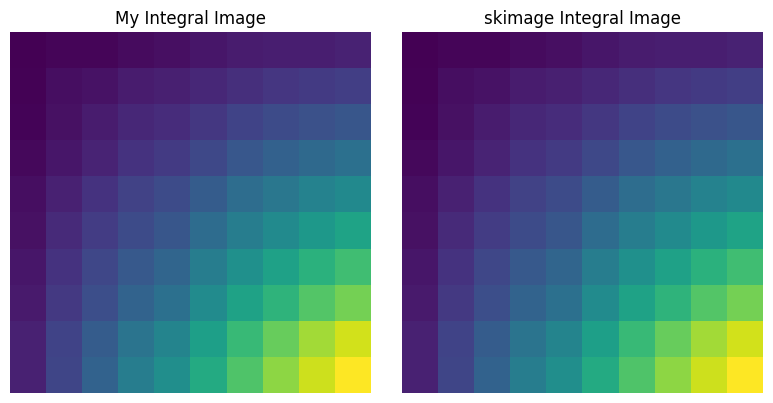

In [ ]:
from skimage.transform import integral_image as sk_integral_image

def compute_integral_image(img):
    """
    Compute the integral image of a 2D numpy array img.
    """
    # Ensure float for safety
    img = img.astype(np.float64)
    # Cumulative sum over rows, then columns
    ii = np.cumsum(np.cumsum(img, axis=0), axis=1)
    return ii

# Example input image (you can also load any grayscale image using skimage.io)
test_img = np.random.rand(10, 10)  # small random example

my_ii = compute_integral_image(test_img)
sk_ii = sk_integral_image(test_img)

print("My integral image shape:", my_ii.shape)
print("skimage integral image shape:", sk_ii.shape)
print("Max absolute difference:", np.abs(my_ii - sk_ii).max())

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(my_ii, cmap='viridis')
axes[0].set_title("My Integral Image")
axes[0].axis('off')
axes[1].imshow(sk_ii, cmap='viridis')
axes[1].set_title("skimage Integral Image")
axes[1].axis('off')
plt.tight_layout()
plt.show()


## One Weak Classifier

* Implementing a weak classifier that uses a single rectangular feature to classify an image as face/non-face. The classifier should take as input the integral image, the feature type, position, size, and threshold. It should output 1 for face, and 0 for non-face predictions.
* Testing the weak classifier on an example image.

We use one cifar image as non-face and one tinyface image as face.

In [ ]:
# Get TinyFace using for example gdown
!pip install gdown
!gdown 1xTZc7lNmWN33ECO2AKH6FycGdiqIK7W0
!unzip tinyface.zip
!rm tinyface.zip

Streaming output truncated to the last 5000 lines.
  inflating: tinyface/Testing_Set/Gallery_Distractor/60_8_Election_Campain_Election_Campaign_8_148_face10.jpg  
  inflating: tinyface/Testing_Set/Gallery_Distractor/60_8_Election_Campain_Election_Campaign_8_244_face15.jpg  
  inflating: tinyface/Testing_Set/Gallery_Distractor/60_8_Election_Campain_Election_Campaign_8_412_face213.jpg  
  inflating: tinyface/Testing_Set/Gallery_Distractor/60_8_Election_Campain_Election_Campaign_8_412_face211.jpg  
  inflating: tinyface/Testing_Set/Gallery_Distractor/60_8_Election_Campain_Election_Campaign_8_412_face202.jpg  
  inflating: tinyface/Testing_Set/Gallery_Distractor/60_8_Election_Campain_Election_Campaign_8_412_face201.jpg  
  inflating: tinyface/Testing_Set/Gallery_Distractor/60_8_Election_Campain_Election_Campaign_8_412_face200.jpg  
  inflating: tinyface/Testing_Set/Gallery_Distractor/60_8_Election_Campain_Election_Campaign_8_412_face199.jpg  
  inflating: tinyface/Testing_Set/Gallery_Distr

In [ ]:
# Prepare tinyface data
import os
import shutil
import torch
import torchvision
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader

def move_files_to_parent(parent_dir):
    for root, dirs, files in os.walk(parent_dir, topdown=False):
        # Move files in subdirectories to the parent directory
        for file in files:
            src = os.path.join(root, file)
            dst = os.path.join(parent_dir, file)
            shutil.move(src, dst)

        # Remove empty subdirectories
        for directory in dirs:
            subdir = os.path.join(root, directory)
            if not os.listdir(subdir):  # Check if the directory is empty
                os.rmdir(subdir)

path = 'tinyface/Training_Set/'
move_files_to_parent(path)

In [ ]:
class TinyFace(Dataset):
    def __init__(self, img_dir, transform=None):
        """
        Args:
            image_dir (str): Path to the directory with all images.
            transform (callable, optional): Optional transform to apply to the images.
        """
        self.image_dir = img_dir
        self.image_filenames = [
            f for f in os.listdir(img_dir) if os.path.isfile(os.path.join(img_dir, f))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        """
        Args:
            idx (int): Index of the image to retrieve.

        Returns:
            image: Transformed image.
            label: Label (optional, could be derived from filenames if needed).
        """
        img_path = os.path.join(self.image_dir, self.image_filenames[idx])
        image = Image.open(img_path).convert("RGB")  # Ensure 3-channel RGB
        if self.transform:
            image = self.transform(image)
        label = 1
        return (image, label)

# Define the transforms for preprocessing
transform = transforms.Compose([
    transforms.Resize((24, 24)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

# Create the dataset
tinyface_dataset = TinyFace(img_dir='tinyface/Training_Set', transform=transform)

# Access a single sample
image, label = tinyface_dataset[0]
print(f"Image shape: {image.shape}, Label: {label}")
print(len(tinyface_dataset))

Image shape: torch.Size([1, 24, 24]), Label: 1
7804


In [ ]:
# Face Data samples done
# Now loading CIFAR-10 dataset as non-face data and prepping it similarly

In [ ]:
# Load CIFAR-10 dataset as non-face data

import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((24, 24)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

cifar10_train = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

cifar10_test = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Setting all targets to 0 (non-face)
cifar10_train.targets = [0] * len(cifar10_train)
cifar10_test.targets = [0] * len(cifar10_test)

# Access samples
image, label = cifar10_train[0]
print(f"Image shape: {image.shape}, Label: {label}")

Image shape: torch.Size([1, 24, 24]), Label: 0


In [ ]:
def rect_sum(ii, x, y, w, h):
    """
    Compute sum of pixels in rectangle using integral image.
    ii: integral image (2D)
    (x, y): top-left coordinate
    w, h: width and height
    """
    # bottom-right corner indices (inclusive in integral-image logic)
    x2 = x + w - 1
    y2 = y + h - 1

    A = ii[y2, x2]
    B = ii[y-1, x2] if y > 0 else 0
    C = ii[y2, x-1] if x > 0 else 0
    D = ii[y-1, x-1] if (x > 0 and y > 0) else 0

    return A - B - C + D

def feature_value(ii, feature):
    """
    Compute 2-rect feature value from integral image.
    feature: dict with keys type ('h2' or 'v2'), x, y, w, h
    """
    x, y, w, h = feature["x"], feature["y"], feature["w"], feature["h"]
    if feature["type"] == "h2":
        w_half = w // 2
        white = rect_sum(ii, x, y, w_half, h)
        black = rect_sum(ii, x + w_half, y, w_half, h)
    else:  # 'v2'
        h_half = h // 2
        white = rect_sum(ii, x, y, w, h_half)
        black = rect_sum(ii, x, y + h_half, w, h_half)
    return white - black

def weak_classifier(ii, feature, threshold, polarity=1):
    """
    Classify using single rectangular feature on integral image.
    Returns 1 for face, 0 for non-face.
    Decision rule: polarity * f(x) < polarity * threshold -> face (1)
    """
    f = feature_value(ii, feature)
    return 1 if polarity * f < polarity * threshold else 0

# Example: test on one TinyFace (face) and one CIFAR-10 (non-face) image

# Take a sample from TinyFace dataset
tiny_img, tiny_label = tinyface_dataset[0]  # tiny_label should be 1
tiny_img_np = tiny_img.squeeze(0).numpy()   # 24x24

# Take a sample from CIFAR-10 dataset
cifar_img, cifar_label = cifar10_train[0]   # target set to 0 earlier
cifar_img_np = cifar_img.squeeze(0).numpy()

# Compute integral images
tiny_ii = compute_integral_image(tiny_img_np)
cifar_ii = compute_integral_image(cifar_img_np)

# Choose a simple feature in the center
simple_feature = {
    "type": "h2",
    "x": 4,
    "y": 4,
    "w": 16,   # even
    "h": 8
}

# Compute feature values
tiny_f = feature_value(tiny_ii, simple_feature)
cifar_f = feature_value(cifar_ii, simple_feature)
print("Feature value (TinyFace):", tiny_f)
print("Feature value (CIFAR-10):", cifar_f)

# Pick a threshold (e.g. mean of two feature values)
threshold = 0.5 * (tiny_f + cifar_f)
print("Threshold:", threshold)

# Classify
tiny_pred = weak_classifier(tiny_ii, simple_feature, threshold, polarity=1)
cifar_pred = weak_classifier(cifar_ii, simple_feature, threshold, polarity=1)

print("TinyFace prediction (1=face, 0=non-face):", tiny_pred)
print("CIFAR-10 prediction (1=face, 0=non-face):", cifar_pred)


Feature value (TinyFace): 7.482353061437607
Feature value (CIFAR-10): -12.407843232154846
Threshold: -2.4627450853586197
TinyFace prediction (1=face, 0=non-face): 0
CIFAR-10 prediction (1=face, 0=non-face): 1


## AdaBoosting

* Implementing the AdaBoost algorithm as outlined in the paper (https://www.face-rec.org/algorithms/Boosting-Ensemble/16981346.pdf).
* Training a 20-feature classifier using these datasets:
    - TinyFace for low resolution face images: https://qmul-tinyface.github.io/
    - CIFAR10 for negative samples: https://www.cs.toronto.edu/~kriz/cifar.html
* Testing the classifier and report the results for different thresholds.

Note: Use torch.utils.data.ConcatDataset to finalize the dataset. If you are more comfortable with numpy or another framework feel free to convert the data accordingly. <br><br>
Example conversion from torch.tensor to numpy: `numpy_array = tensor.numpy()`

In [ ]:
from torch.utils.data import ConcatDataset, Subset
import numpy as np

# Balance the dataset: take equal number of faces and non-faces
N_SAMPLES = 1000  # adjust based on your runtime
face_indices = np.random.choice(len(tinyface_dataset), min(N_SAMPLES, len(tinyface_dataset)), replace=False)
nonface_indices = np.random.choice(len(cifar10_train), N_SAMPLES, replace=False)

# Create balanced subsets using Subset
face_subset = Subset(tinyface_dataset, face_indices)
nonface_subset = Subset(cifar10_train, nonface_indices)

# Training set: balanced
train_dataset = ConcatDataset([face_subset, nonface_subset])

# Test set: first 200 from each (using proper Subset)
test_face_indices = np.arange(min(200, len(tinyface_dataset)))
test_nonface_indices = np.arange(200)
test_face_subset = Subset(tinyface_dataset, test_face_indices)
test_nonface_subset = Subset(cifar10_test, test_nonface_indices)
test_dataset = ConcatDataset([test_face_subset, test_nonface_subset])

print(f"Training set: {len(train_dataset)} samples ({len(face_subset)} faces + {len(nonface_subset)} non-faces)")
print(f"Test set: {len(test_dataset)} samples")

# Convert to numpy for easier processing
def dataset_to_numpy(dataset):
    images, labels = [], []
    for img, label in dataset:
        img_np = img.squeeze(0).numpy()
        images.append(img_np)
        labels.append(label)
    return np.array(images), np.array(labels)

X_train, y_train = dataset_to_numpy(train_dataset)
X_test, y_test = dataset_to_numpy(test_dataset)

# Compute integral images for all training/test images
X_train_ii = np.array([compute_integral_image(img) for img in X_train])
X_test_ii = np.array([compute_integral_image(img) for img in X_test])

print("X_train_ii shape:", X_train_ii.shape)
print("y_train shape:", y_train.shape)


Training set: 2000 samples (1000 faces + 1000 non-faces)
Test set: 400 samples
X_train_ii shape: (2000, 24, 24)
y_train shape: (2000,)


In [ ]:
def adaboost_train(X_ii, y, n_classifiers=20):
    """
    AdaBoost: sample 1000 random features per iteration instead of all 15k+
    """
    N = len(y)
    D = np.ones(N) / N
    all_features = generate_two_rect_features(24)

    classifiers = []

    for t in range(n_classifiers):
        min_error = float('inf')
        best_feature, best_threshold, best_polarity = None, None, None

        # SAMPLE 1000 random features instead of all 15k+ (1000x speedup!)
        sample_indices = np.random.choice(len(all_features), 1000, replace=False)
        sample_features = [all_features[i] for i in sample_indices]

        for feature in sample_features:
            feature_values = np.array([feature_value(ii, feature) for ii in X_ii])

            # Trying 10 thresholds instead of all possible values
            for thresh_percentile in np.linspace(20, 80, 10):
                threshold = np.percentile(feature_values, thresh_percentile)
                for polarity in [1, -1]:
                    predictions = (polarity * feature_values < polarity * threshold).astype(int)
                    error = np.sum(D * (predictions != y))

                    if error < min_error:
                        min_error = error
                        best_feature = feature
                        best_threshold = threshold
                        best_polarity = polarity

        # Compute alpha and update weights (same as before)
        epsilon = min_error / np.sum(D)
        alpha = 0.5 * np.log((1 - epsilon) / (epsilon + 1e-10))

        feature_values = np.array([feature_value(ii, best_feature) for ii in X_ii])
        predictions = (best_polarity * feature_values < best_polarity * best_threshold).astype(int)
        D = D * np.exp(alpha * (predictions != y))
        D /= np.sum(D)

        classifiers.append((best_feature, best_threshold, best_polarity, alpha))
        print(f"Iter {t+1}: error={min_error:.3f}, alpha={alpha:.3f}")

    return classifiers

def adaboost_predict(X_ii, classifiers):
    N = len(X_ii)
    scores = np.zeros(N)

    for feature, threshold, polarity, alpha in classifiers:
        feature_values = np.array([feature_value(ii, feature) for ii in X_ii])
        h = (polarity * feature_values < polarity * threshold).astype(int)
        scores += alpha * (2 * h - 1)

    return (scores > 0).astype(int)

# Train  AdaBoost
print("Training AdaBoost (20 classifiers)...")
classifiers = adaboost_train(X_train_ii, y_train, n_classifiers=20)

# Test performance
y_pred_train = adaboost_predict(X_train_ii, classifiers)
y_pred_test = adaboost_predict(X_test_ii, classifiers)

train_acc = np.mean(y_pred_train == y_train)
test_acc = np.mean(y_pred_test == y_test)

print("\n" + "="*50)
print("AdaBoost Results (20 classifiers)")
print("="*50)
print(f"Training accuracy: {train_acc:.3f}")
print(f"Test accuracy:    {test_acc:.3f}")


Training AdaBoost (20 classifiers)...
Iter 1: error=0.259, alpha=0.526
Iter 2: error=0.335, alpha=0.343
Iter 3: error=0.346, alpha=0.318
Iter 4: error=0.362, alpha=0.284
Iter 5: error=0.344, alpha=0.322
Iter 6: error=0.373, alpha=0.259
Iter 7: error=0.356, alpha=0.297
Iter 8: error=0.387, alpha=0.230
Iter 9: error=0.389, alpha=0.226
Iter 10: error=0.385, alpha=0.235
Iter 11: error=0.394, alpha=0.215
Iter 12: error=0.370, alpha=0.265
Iter 13: error=0.399, alpha=0.204
Iter 14: error=0.400, alpha=0.203
Iter 15: error=0.398, alpha=0.206
Iter 16: error=0.403, alpha=0.196
Iter 17: error=0.396, alpha=0.211
Iter 18: error=0.409, alpha=0.185
Iter 19: error=0.397, alpha=0.209
Iter 20: error=0.399, alpha=0.205

AdaBoost Results (20 classifiers)
Training accuracy: 0.859
Test accuracy:    0.848
